# Tạo profile cái này sẽ lưu trong database

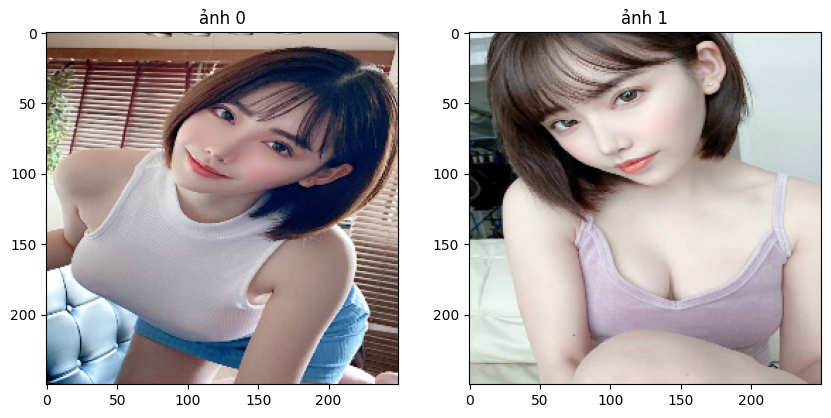

Trích xuất thành công
{'status': 'success', 'num_images': 2, 'vector': [0.00491824746131897, -0.06274504959583282, -0.07586471736431122, 0.03421968221664429, -0.06580165028572083, 0.04204896464943886, -0.08765989542007446, 0.014708609320223331, -0.023181237280368805, -0.0017161353025585413, -0.013661067932844162, 0.05113385617733002, -0.0010933082085102797, 0.04021550714969635, 0.043914515525102615, 0.03419366851449013, 0.07554139941930771, 0.02977314218878746, -0.0613744892179966, 0.025277500972151756, 0.07831919193267822, 0.0027812717016786337, 0.007309122942388058, -0.0308945644646883, -0.019628990441560745, -0.027544599026441574, 0.026737425476312637, 0.01007377915084362, 0.05127862095832825, 0.05619719997048378, -0.031677406281232834, -0.029615869745612144, -0.00624495605006814, -0.027320371940732002, 0.0657983273267746, 0.03530143201351166, 0.03348539024591446, -0.04322131350636482, -0.053118620067834854, -0.009133808314800262, 0.0643424466252327, -0.06090828403830528, -0.0369681

In [ ]:
import requests
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow
url = "https://aiwho-embeddingresnet34.hf.space/extract_profile"

image_path = ["img_1.jpg","img_2.jpg"] # có thể up tối đa 5 ảnh để tạo profile nhìn thẳng , ngước lên , cúi xuống ,sang trái , phải
fig , axes  = plt.subplots(1,2,figsize=(10,10))
# show vài ảnh
for i,img in enumerate(image_path):
    img = cv2.imread(img)
    img  = cv2.resize(img,(250,250))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    axes[i].set_title(f"ảnh {i}")
    axes[i].imshow(img)
plt.show()
img_byte=[]
for img in image_path:
      img_file = open(img,"rb")
      img_byte.append(("files",img_file))

response = requests.post(url, files=img_byte)

if response.status_code == 200:
    print("Trích xuất thành công")
    vector_data = response.json()
    print(vector_data)
    vector_profile = vector_data["vector"]
else:
    print(f"Lỗi: {response.status_code}")
    print(response.text)

# ảnh cần so khớp với profile

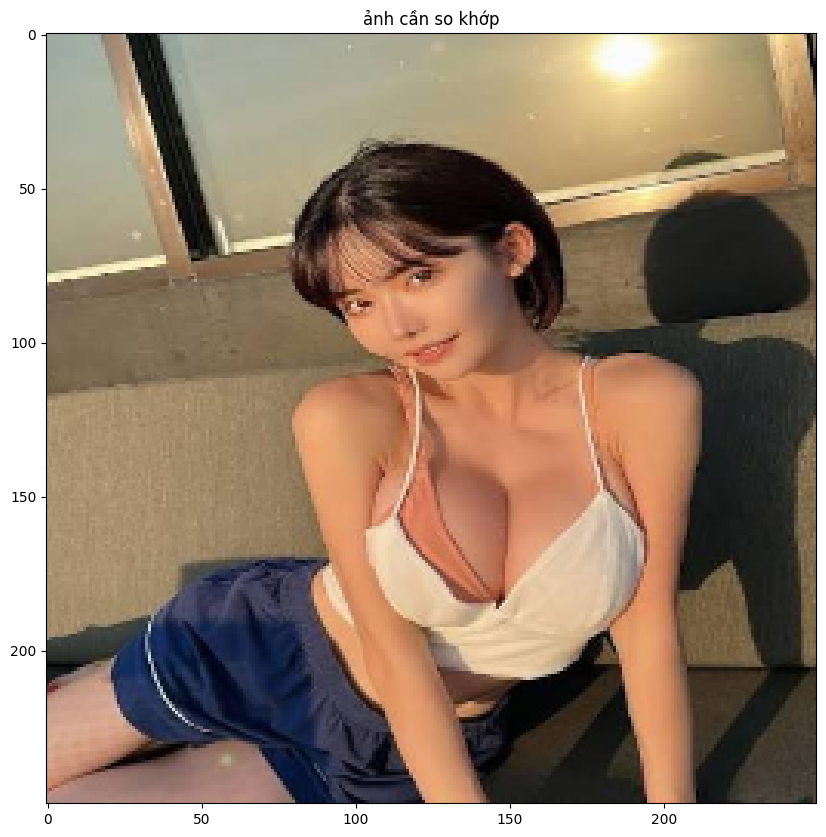

In [ ]:
img_path = "img_3.jpg"
img=cv2.imread("img_3.jpg")
img  = cv2.resize(img,(250,250))
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
fig,axes = plt.subplots(1,1,figsize=(10,10))
axes.set_title("ảnh cần so khớp")
axes.imshow(img)
plt.show()

In [ ]:
img_in = open(img_path,"rb")
url_extract = "https://aiwho-embeddingresnet34.hf.space/extract_single"
response = requests.post(url,files={"files":img_in})
print(response.text)
vector_img = response.json()['vector']


{"status":"success","num_images":1,"vector":[0.004827508702874184,-0.10714338719844818,-0.06374040991067886,0.0510026216506958,-0.04350448399782181,0.09433332085609436,-0.06421919167041779,-0.060143787413835526,-0.021506620571017265,-0.025757696479558945,-0.0250940453261137,-0.024751005694270134,0.009091575630009174,0.014175646007061005,0.017736494541168213,0.05944213271141052,0.0502237007021904,0.06111353635787964,-0.07831764966249466,0.046958841383457184,0.08680804818868637,0.046576231718063354,0.012695947661995888,0.033411309123039246,-0.06103923171758652,-0.04489065706729889,-0.04527055099606514,-0.002155496273189783,0.0008849011501297355,0.04631459340453148,-0.031928651034832,-0.03466955944895744,-0.015067818574607372,-0.03996884450316429,0.05733584240078926,0.023550495505332947,0.058631666004657745,0.012903295457363129,0.004105145111680031,-0.019224701449275017,0.01610558293759823,-0.08181339502334595,0.007564359810203314,0.06695234775543213,0.032209429889917374,-0.03882626816630

# so khớp bằng cosin

In [ ]:
import numpy as np
def cosine_similarity(a, b):
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return np.dot(a,b)/(norm_a*norm_b)

# độ tương đồng giữa ảnh so khớp và profile là

In [ ]:
print(cosine_similarity(vector_img,vector_profile)*100)

67.49915890833586
